In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

### Observation
The required libraries were imported for data manipulation, visualization, model training, and performance evaluation.

In [2]:
df = pd.read_csv("data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Feature and Target Split

In [3]:
X = df.drop("Class",axis =1 )
y = df["Class"]
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


### Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Observation
The dataset was split into training and testing sets while preserving the original class distribution using stratified sampling.

### Train Random Forest

In [6]:
rf_model = RandomForestClassifier(n_estimators =100,random_state=42, n_jobs =-1 )

rf_model.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### Observation
A Random Forest classifier was trained using the training dataset. The model combines predictions from multiple decision trees to improve classification performance and reduce overfitting.

### Generate Predictions

In [7]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

### Observation

Predicted class labels and fraud probabilities were generated for the test dataset.

### Classification Report

In [8]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



### Observation
The Random Forest model achieved excellent fraud detection performance, with a precision of 94%, recall of 82%, and an F1-score of 87% for the fraud class. Compared to the baseline Logistic Regression model, Random Forest improved both precision and recall, indicating a stronger ability to identify fraudulent transactions while minimizing false fraud alerts. These results suggest that Random Forest provides a more balanced and effective solution for fraud detection.

### Confusion Matrix

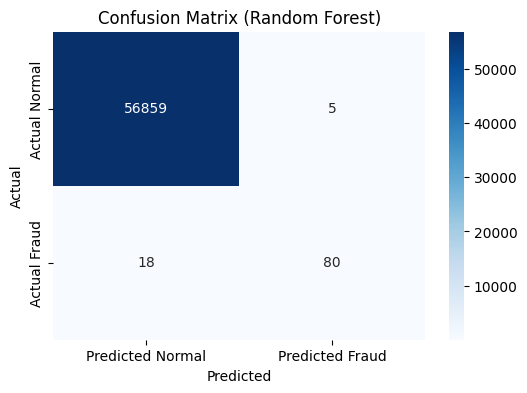

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Normal",
        "Predicted Fraud"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Fraud"
    ]
)

plt.title(
    "Confusion Matrix (Random Forest)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation
The confusion matrix indicates that the Random Forest model achieved excellent classification performance. The model correctly identified 80 fraudulent transactions while missing only 18 fraud cases. Additionally, it generated only 5 false fraud alerts among more than 56,000 legitimate transactions. Compared with previous models, Random Forest achieved a strong balance between fraud detection capability and minimizing false positive predictions.

### ROC-AUC Score

In [10]:
auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(
    "ROC-AUC Score:",
    auc_rf
)





ROC-AUC Score: 0.9630272515590367


### Observation
The Random Forest model achieved a ROC-AUC score of 0.9630, indicating excellent ability to distinguish between fraudulent and legitimate transactions across different classification thresholds. The score is higher than the baseline Logistic Regression model (0.9525), demonstrating improved discriminatory performance.Although the ROC-AUC is slightly lower than the SMOTE-enhanced Logistic Regression model (0.9775), Random Forest achieved substantially higher precision and far fewer false positives, making it a strong candidate for fraud detection.


### ROC Curve

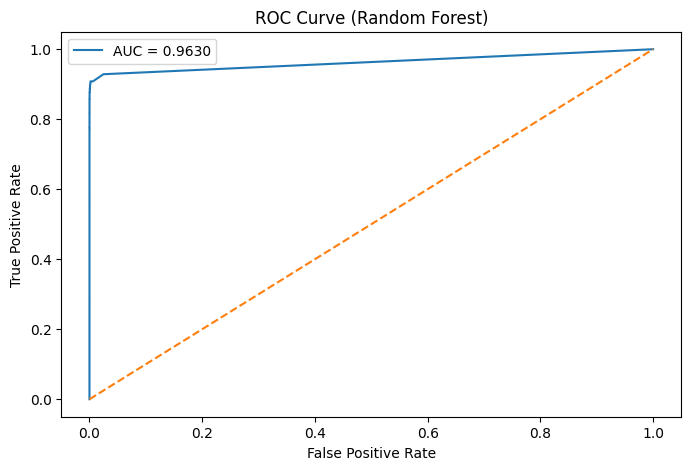

In [11]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_rf:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve (Random Forest)"
)

plt.legend()

plt.show()

### Observation
The ROC curve lies close to the top-left corner of the graph and remains well above the random-classification baseline, indicating excellent classification performance. The Random Forest model achieved a ROC-AUC score of 0.9630, demonstrating a strong ability to distinguish between fraudulent and legitimate transactions across different classification thresholds. Although the ROC-AUC score is slightly lower than that of the SMOTE-enhanced Logistic Regression model, the Random Forest model achieved significantly higher precision and substantially fewer false positive predictions, making it a more balanced fraud detection solution.

### Compare With Previous Models



In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        0.82,
        0.65,
        0.73,
        0.9525
    ],
    "Logistic + SMOTE": [
        0.13,
        0.90,
        0.23,
        0.9775
    ],
    "Random Forest": [
        0.94,
        0.82,
        0.87,
        0.9630
    ]
})

comparison

,Metric,Logistic Regression,Logistic + SMOTE,Random Forest
0,Precision,0.8200,0.1300,0.940
1,Recall,0.6500,0.9000,0.820
2,F1-Score,0.7300,0.2300,0.870
3,ROC-AUC,0.9525,0.9775,0.963


### Observation
The comparison shows that each model has trade-offs. Logistic Regression produced relatively few false alarms but missed more fraud cases. Logistic Regression with SMOTE detected the most fraud but generated many false positives. Random Forest achieved the best balance between fraud detection and false positive control, making it the strongest model evaluated so far.

### notebook conclusion
The Random Forest model was evaluated as an alternative to Logistic Regression for credit card fraud detection. The model achieved a precision of 94%, recall of 82%, F1-score of 87%, and a ROC-AUC score of 0.9630, demonstrating excellent classification performance. Compared to the baseline Logistic Regression model, Random Forest improved fraud detection capability while maintaining a very low number of false positive predictions. Although the SMOTE-enhanced Logistic Regression model achieved higher recall and ROC-AUC values, it generated a substantially larger number of false fraud alerts. Overall, Random Forest provided the best balance between detecting fraudulent transactions and minimizing unnecessary investigations, making it the strongest model evaluated in this project so far.
